# Extended Data Figure 5 — Venn diagram of L2G gene prioritisation reasons

Four-way Venn diagram showing the overlap between four direct reasons a (CS, gene) pair
is prioritised by the L2G model:

- **eQTL colocalisation**
- **pQTL colocalisation**
- **VEP** — protein-altering variant
- **TSS** — nearest transcription start site

Numbers indicate the count of CS–gene prioritisations in each overlap region.

**Data:** `data/intermediate_files/list_of_prioritised_genes_per_CS.parquet`


## Load data


In [36]:
import pandas as pd

path_intermediate = "../../../data/intermediate_files/"

# Load prioritised CS-gene pairs and restrict to qualifying disease + measurement CSs
l2g = pd.read_parquet(path_intermediate + "list_of_prioritised_genes_per_CS.parquet")

qd_cs = pd.read_parquet(path_intermediate + "qualifying_credible_sets", columns=["studyLocusId"])
qm_cs = pd.read_parquet(path_intermediate + "qualifying_measurement_credible_sets", columns=["studyLocusId"])
qualifying_cs = pd.concat([qd_cs, qm_cs]).drop_duplicates()

l2g = l2g.merge(qualifying_cs, on="studyLocusId", how="inner")
print(f"L2G prioritised CS-gene pairs (disease + measurement CSs): {len(l2g):,}")
print(l2g[["eQTL_coloc", "pQTL_coloc", "VEP", "distanceTSS"]].sum().to_string())


L2G prioritised CS-gene pairs (disease + measurement CSs): 523,409
eQTL_coloc     191871
pQTL_coloc      30030
VEP             63327
distanceTSS    424781


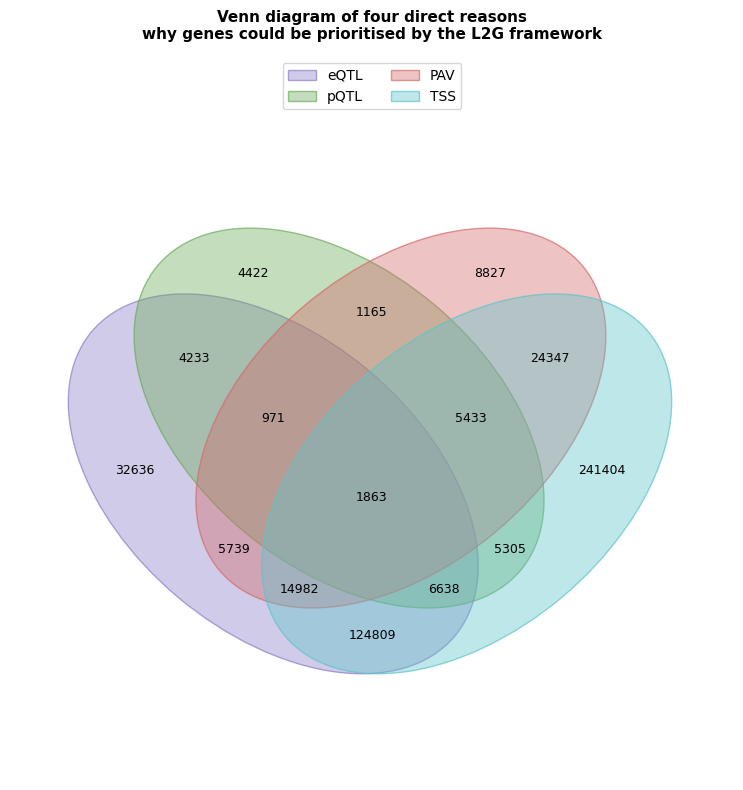

26/04/15 20:33:29 WARN TransportChannelHandler: Exception in connection from mib118093s.internal.sanger.ac.uk/172.20.240.209:49971
java.io.IOException: Operation timed out
	at java.base/sun.nio.ch.FileDispatcherImpl.read0(Native Method)
	at java.base/sun.nio.ch.SocketDispatcher.read(SocketDispatcher.java:39)
	at java.base/sun.nio.ch.IOUtil.readIntoNativeBuffer(IOUtil.java:276)
	at java.base/sun.nio.ch.IOUtil.read(IOUtil.java:233)
	at java.base/sun.nio.ch.IOUtil.read(IOUtil.java:223)
	at java.base/sun.nio.ch.SocketChannelImpl.read(SocketChannelImpl.java:356)
	at io.netty.buffer.PooledByteBuf.setBytes(PooledByteBuf.java:254)
	at io.netty.buffer.AbstractByteBuf.writeBytes(AbstractByteBuf.java:1132)
	at io.netty.channel.socket.nio.NioSocketChannel.doReadBytes(NioSocketChannel.java:357)
	at io.netty.channel.nio.AbstractNioByteChannel$NioByteUnsafe.read(AbstractNioByteChannel.java:151)
	at io.netty.channel.nio.NioEventLoop.processSelectedKey(NioEventLoop.java:788)
	at io.netty.channel.nio.Ni

In [39]:
import matplotlib.pyplot as plt
import venn

ids = l2g["studyLocusId"] + "_" + l2g["geneId"]

sets = {
    "eQTL": set(ids[l2g["eQTL_coloc"] == 1]),
    "pQTL": set(ids[l2g["pQTL_coloc"] == 1]),
    "PAV": set(ids[l2g["VEP"] == 1]),
    "TSS": set(ids[l2g["distanceTSS"] == 1]),
}

fig, ax = plt.subplots(figsize=(8, 8))
venn.venn(sets, ax=ax, fontsize=9, legend_loc="center", cmap=["#8B7FC7", "#6AAC5B", "#D46A6A", "#5EC4CB"])

# Reformat legend to 2 columns
ax.legend(
    handles=ax.get_legend().legend_handles,
    labels=["eQTL", "pQTL", "PAV", "TSS"],
    loc="upper center",
    ncols=2,
    fontsize=10,
    frameon=True,
)

ax.set_title(
    "Venn diagram of four direct reasons\nwhy genes could be prioritised by the L2G framework",
    fontsize=11,
    fontweight="bold",
    pad=12,
)

fig.tight_layout()
fig.savefig("extended_figure_5.pdf", dpi=300, bbox_inches="tight")
plt.show()
